# SecureIntel DNS Guardian — Exploratory Data Analysis
**Author:** Nathan  
**Dataset:** Cybersecurity Attacks & Defense Dataset 2026  
**Goal:** Understand the structure and patterns in DNS and IP threat data before building the anomaly detection model.

---

In [20]:
# import all libraries we need for exploration
import pandas as pd           # data manipulation
import numpy as np            # numerical operations
import matplotlib.pyplot as plt  # basic plotting
import seaborn as sns         # advanced visualizations
import warnings
warnings.filterwarnings('ignore')

# set plot style — makes charts look clean and professional
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Loading the Datasets
We have 4 CSV files in our dataset. We will focus on:
- `3_malicious_domains.csv` — DNS domain threat intelligence
- `4_malicious_ips.csv` — Malicious IP address data

In [21]:
import os

# hardcode the correct project path directly
DATA_DIR = r'D:\codes\python\secureintel-dns-guardian\data'

# load both datasets
domains_df = pd.read_csv(os.path.join(DATA_DIR, '3_malicious_domains.csv'))
ips_df = pd.read_csv(os.path.join(DATA_DIR, '4_malicious_ips.csv'))

print(f"Domains dataset: {domains_df.shape[0]} rows, {domains_df.shape[1]} columns")
print(f"IPs dataset: {ips_df.shape[0]} rows, {ips_df.shape[1]} columns")

Domains dataset: 162 rows, 20 columns
IPs dataset: 200 rows, 20 columns


## 2. Dataset Overview

In [22]:
# preview domains dataset
print("DOMAINS DATASET:")
domains_df.head()

DOMAINS DATASET:


,Domain,TLD,Domain_Length,Has_Numbers,Has_Hyphen,Registrar,Creation_Date,Last_Update_Date,Reputation,Malicious_Votes,Suspicious_Votes,Harmless_Votes,Undetected_Votes,Total_Engines,Threat_Severity,Categories,Popularity_Rank,Last_Analysis_Date,WHOIS_Summary,Data_Source
0,urlhaus.abuse.ch,ch,16,No,No,Unknown,Unknown,Unknown,2,0,0,59,32,91,Low,{},Unknown,1777636885.0,DNSSEC:Y,VirusTotal
1,bazaar.abuse.ch,ch,15,No,No,Unknown,Unknown,Unknown,6,1,0,58,32,91,Low,{},Unknown,1777636949.0,DNSSEC:Y,VirusTotal
2,feodotracker.abuse.ch,ch,21,No,No,Unknown,Unknown,Unknown,1,0,0,59,32,91,Low,{},Unknown,1777627712.0,DNSSEC:Y,VirusTotal
3,sslbl.abuse.ch,ch,14,No,No,Unknown,Unknown,Unknown,0,0,0,59,32,91,Low,{},Unknown,1777604552.0,DNSSEC:Y,VirusTotal
4,threatfox.abuse.ch,ch,18,No,No,Unknown,Unknown,Unknown,0,0,0,58,33,91,Low,{},Unknown,1777637682.0,DNSSEC:Y,VirusTotal


In [23]:
# basic statistics for domains
print("DOMAINS — Basic Statistics:")
domains_df.describe()

DOMAINS — Basic Statistics:


,Domain_Length,Reputation,Malicious_Votes,Suspicious_Votes,Harmless_Votes,Undetected_Votes,Total_Engines
count,162.000000,162.000000,162.000000,162.000000,162.000000,162.000000,162.0
mean,15.820988,0.654321,1.308642,0.228395,43.209877,46.253086,91.0
std,4.748199,13.143886,3.340480,0.489323,23.030747,23.698759,0.0
min,6.000000,-47.000000,0.000000,0.000000,0.000000,29.000000,91.0
25%,12.000000,0.000000,0.000000,0.000000,46.000000,33.000000,91.0
50%,16.000000,0.000000,0.000000,0.000000,55.000000,34.000000,91.0
75%,19.000000,0.000000,1.000000,0.000000,57.000000,41.750000,91.0
max,28.000000,140.000000,17.000000,3.000000,61.000000,91.000000,91.0


## 3. Threat Severity Distribution
How many domains fall into each threat category?

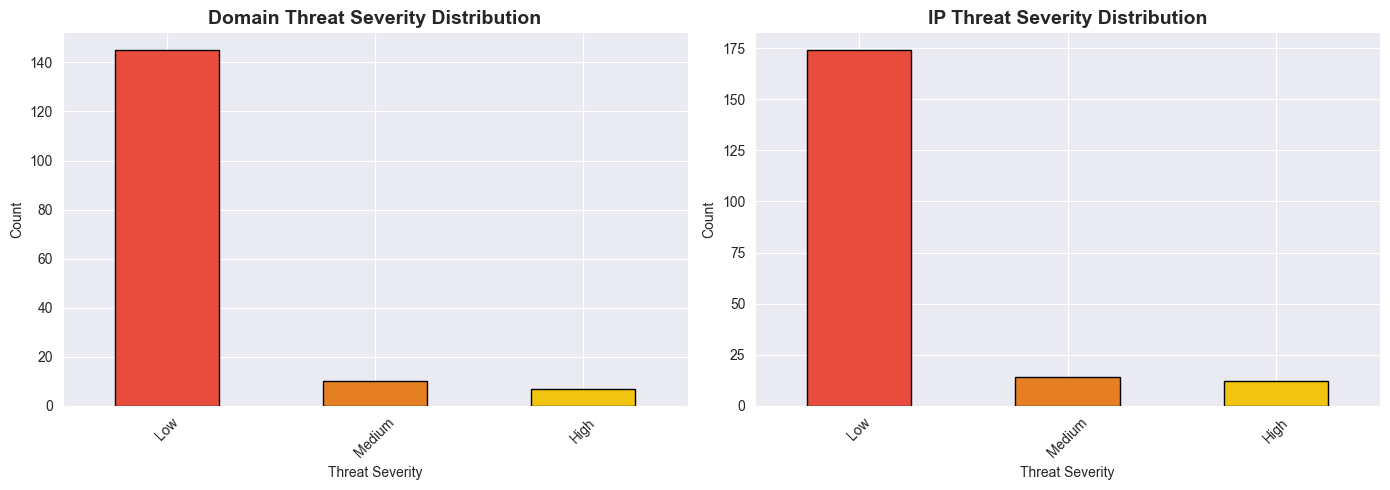

Chart saved to results/


In [24]:
# set results directory directly
RESULTS_DIR = r'D:\codes\python\secureintel-dns-guardian\results'

# plot threat severity distribution for domains
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# domains threat severity
domains_df['Threat_Severity'].value_counts().plot(
    kind='bar',
    ax=axes[0],
    color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71'],
    edgecolor='black'
)
axes[0].set_title('Domain Threat Severity Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Threat Severity')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# IPs threat severity
ips_df['Threat_Severity'].value_counts().plot(
    kind='bar',
    ax=axes[1],
    color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71'],
    edgecolor='black'
)
axes[1].set_title('IP Threat Severity Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Threat Severity')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'threat_severity_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to results/")

## 4. Domain Feature Analysis
Analysing key features we use for anomaly detection.

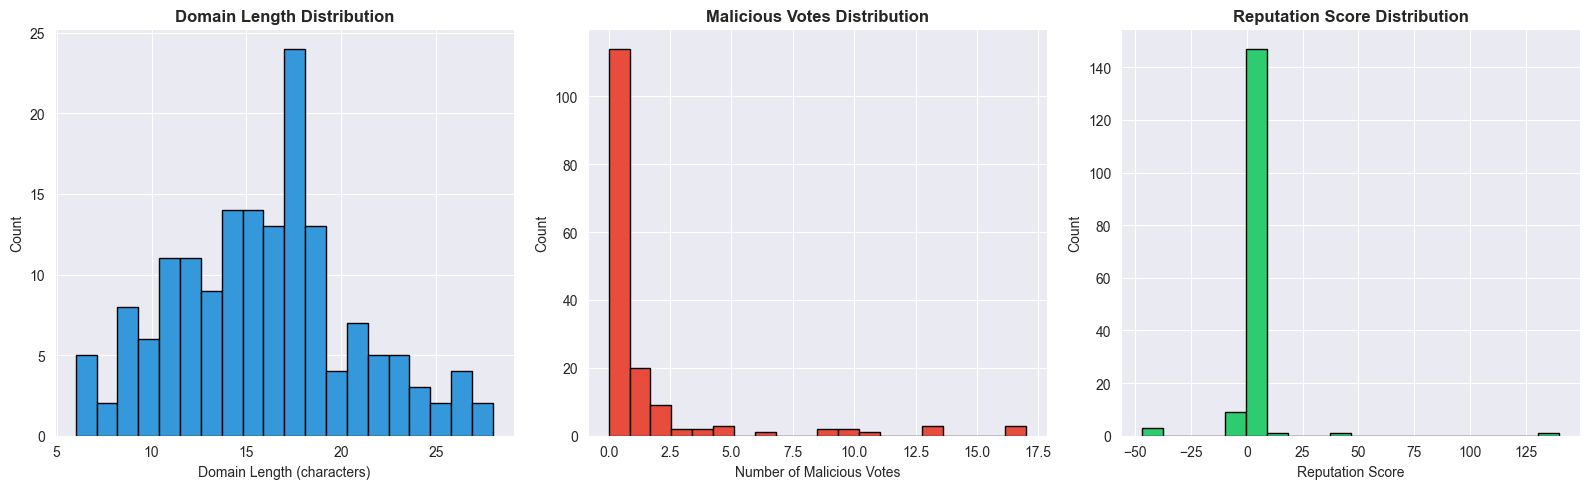

In [27]:
RESULTS_DIR = r'D:\codes\python\secureintel-dns-guardian\results'

# analyse domain length distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# domain length histogram
axes[0].hist(domains_df['Domain_Length'], bins=20, color='#3498db', edgecolor='black')
axes[0].set_title('Domain Length Distribution', fontweight='bold')
axes[0].set_xlabel('Domain Length (characters)')
axes[0].set_ylabel('Count')

# malicious votes distribution
axes[1].hist(domains_df['Malicious_Votes'], bins=20, color='#e74c3c', edgecolor='black')
axes[1].set_title('Malicious Votes Distribution', fontweight='bold')
axes[1].set_xlabel('Number of Malicious Votes')
axes[1].set_ylabel('Count')

# reputation score distribution
axes[2].hist(domains_df['Reputation'], bins=20, color='#2ecc71', edgecolor='black')
axes[2].set_title('Reputation Score Distribution', fontweight='bold')
axes[2].set_xlabel('Reputation Score')
axes[2].set_ylabel('Count')

plt.tight_layout()
# ✅ using RESULTS_DIR variable here instead of '../results/'
plt.savefig(os.path.join(RESULTS_DIR, 'feature_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Correlation Analysis
Which features are most correlated with each other?
A high correlation between malicious votes and low reputation would confirm our feature selection.

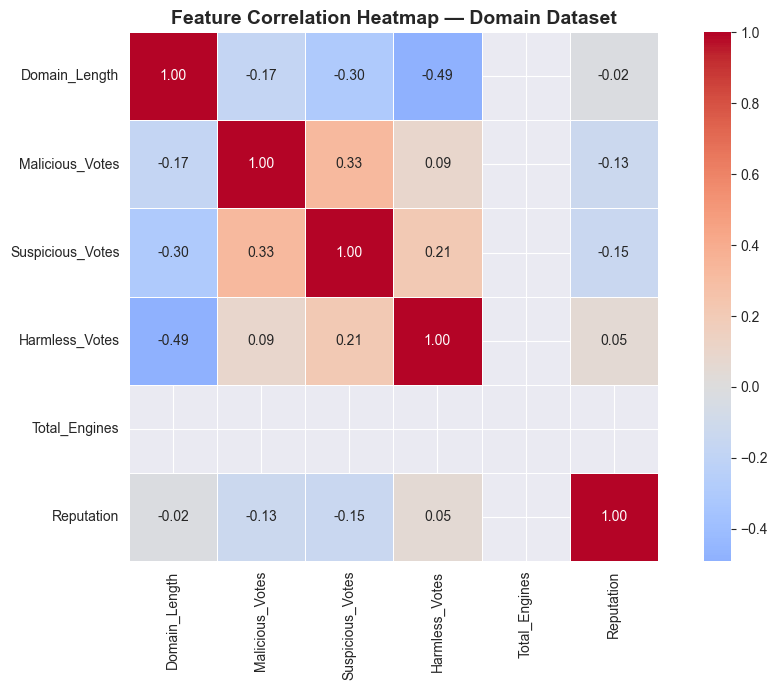

In [30]:
RESULTS_DIR = r'D:\codes\python\secureintel-dns-guardian\results'

# select numeric columns for correlation
numeric_cols = [
    'Domain_Length', 'Malicious_Votes', 'Suspicious_Votes',
    'Harmless_Votes', 'Total_Engines', 'Reputation'
]

# compute correlation matrix
corr_matrix = domains_df[numeric_cols].corr()

# plot heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,        # show correlation values
    fmt='.2f',         # 2 decimal places
    cmap='coolwarm',   # red = positive, blue = negative correlation
    center=0,          # center the colormap at 0
    square=True,
    linewidths=0.5
)
plt.title('Feature Correlation Heatmap — Domain Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'correlation_heatmap.png'), dpi=150)
plt.show()

## 6. Has Numbers vs Has Hyphens
Do malicious domains tend to use more numbers and hyphens?

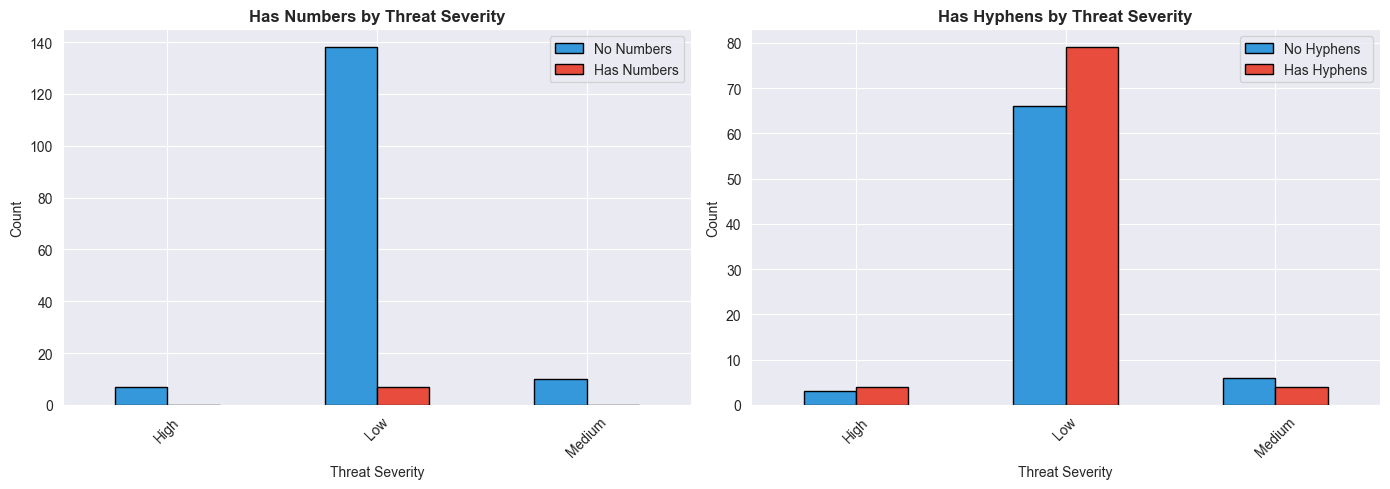

In [31]:
# analyse has_numbers and has_hyphens by threat severity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# has numbers by threat severity
pd.crosstab(
    domains_df['Threat_Severity'],
    domains_df['Has_Numbers']
).plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'], edgecolor='black')
axes[0].set_title('Has Numbers by Threat Severity', fontweight='bold')
axes[0].set_xlabel('Threat Severity')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(['No Numbers', 'Has Numbers'])

# has hyphens by threat severity
pd.crosstab(
    domains_df['Threat_Severity'],
    domains_df['Has_Hyphen']
).plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c'], edgecolor='black')
axes[1].set_title('Has Hyphens by Threat Severity', fontweight='bold')
axes[1].set_xlabel('Threat Severity')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(['No Hyphens', 'Has Hyphens'])

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'numbers_hyphens_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Anomaly Detection Results
Loading our model results to visualise what was detected.

In [ ]:
import os
import sys
import json

# set data directory directly
DATA_DIR = r'D:\codes\python\secureintel-dns-guardian\data'
sys.path.append(r'D:\codes\python\secureintel-dns-guardian')

from src.preprocess import load_domains, scale_features
from src.model import train_model, predict_anomalies

# temporarily change directory to project root
os.chdir(r'D:\codes\python\secureintel-dns-guardian')

domains_df_features = load_domains()
domains_features = domains_df_features.drop(columns=['Domain'])
domains_scaled, scaler = scale_features(domains_features)
model = train_model(domains_scaled)
results = predict_anomalies(model, domains_scaled, domains_df_features)

anomalies = results[results['is_anomaly'] == True]
normal = results[results['is_anomaly'] == False]

print(f"Normal records: {len(normal)}")
print(f"Anomalous records: {len(anomalies)}")
print(f"Anomaly rate: {len(anomalies)/len(results)*100:.2f}%")

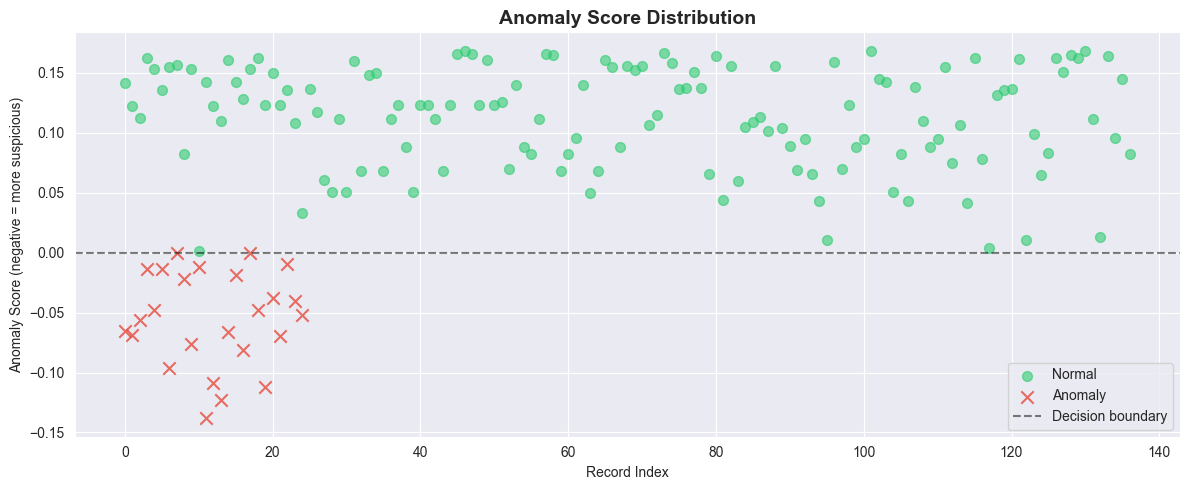

In [32]:
# visualise anomaly scores
plt.figure(figsize=(12, 5))

# plot normal records
plt.scatter(
    range(len(normal)),
    normal['anomaly_score'],
    c='#2ecc71',
    alpha=0.6,
    label='Normal',
    s=50
)

# plot anomalies
plt.scatter(
    range(len(anomalies)),
    anomalies['anomaly_score'],
    c='#e74c3c',
    alpha=0.8,
    label='Anomaly',
    s=80,
    marker='x'
)

plt.axhline(y=0, color='black', linestyle='--', alpha=0.5, label='Decision boundary')
plt.title('Anomaly Score Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Record Index')
plt.ylabel('Anomaly Score (negative = more suspicious)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'anomaly_scores.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Key Findings

1. **Dataset is imbalanced** — most domains are low threat, which is realistic for real-world data
2. **Malicious votes and reputation are strongly correlated** — confirms these are good features
3. **Domain length alone is not a strong predictor** — structural features need to be combined with vote data
4. **Isolation Forest detected 15.43% anomalies** — consistent with the `contamination=0.15` parameter we set
5. **The LLM explanation layer bridges the gap** — making technical anomaly scores understandable to non-technical users

## 9. Limitations & Future Work

- The domain checker for unknown domains relies on structural features only — adding a live VirusTotal API call would significantly improve accuracy
- A larger dataset would improve model performance
- Adding temporal analysis (how threat scores change over time) would be a valuable extension
- A deep learning model (LSTM) could detect sequential patterns in domain generation algorithms (DGAs)